In [3]:
def MCP_Neurons_AND(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Test
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

print(MCP_Neurons_AND(X1, X2, T))

[0, 0, 0, 1]


In [4]:
def MCP_Neurons_OR(X1, X2, T):
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]

        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Test
T = 1
print(MCP_Neurons_OR(X1, X2, T))

[0, 1, 1, 1]


Q1: Limitations of MCP Neuron
- No learning ability
- Fixed weights and threshold
- Cannot solve non-linear problems (like XOR)
- Only binary inputs/outputs
- No adaptability

Q2: XOR using MCP
- Not possible using single MCP neuron
- Can be done using:
  XOR = (A OR B) AND (NOT (A AND B))
- Requires multiple neurons

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:

import pandas as pd
import numpy as np

df = pd.read_csv("/content/drive/MyDrive/AI_ML/Data/mnist_0_and_1.csv")

X = df.drop(columns=["label"]).values
y = df["label"].values

print(X.shape)
print(y.shape)


(12665, 784)
(12665,)


Q1: Shape of X
- Represents (number of samples, number of features)

Q2: Shape of y
- Represents labels for each sample

In [9]:
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

Q3: Weights represent importance of each pixel

Q4: Initialized to zero to start learning from scratch without bias

In [10]:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

In [11]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0

            if y_hat == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_hat) * X[i]
                bias = bias + learning_rate * (y[i] - y_hat)

        accuracy = correct / len(X)
        print("Epoch", epoch+1, "Accuracy:", accuracy)

    return weights, bias, accuracy

In [12]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1 Accuracy: 0.9966837741808132
Epoch 2 Accuracy: 0.9981839715752072
Epoch 3 Accuracy: 0.9986577181208054
Epoch 4 Accuracy: 0.9986577181208054
Epoch 5 Accuracy: 0.9989735491512041
Epoch 6 Accuracy: 0.9992893801816028
Epoch 7 Accuracy: 0.9997631267272009
Epoch 8 Accuracy: 0.9995262534544019
Epoch 9 Accuracy: 0.9988945913936044
Epoch 10 Accuracy: 0.9992104224240032
Epoch 11 Accuracy: 0.9995262534544019
Epoch 12 Accuracy: 0.9997631267272009
Epoch 13 Accuracy: 1.0
Epoch 14 Accuracy: 1.0
Epoch 15 Accuracy: 1.0
Epoch 16 Accuracy: 1.0
Epoch 17 Accuracy: 1.0
Epoch 18 Accuracy: 1.0
Epoch 19 Accuracy: 1.0
Epoch 20 Accuracy: 1.0
Epoch 21 Accuracy: 1.0
Epoch 22 Accuracy: 1.0
Epoch 23 Accuracy: 1.0
Epoch 24 Accuracy: 1.0
Epoch 25 Accuracy: 1.0
Epoch 26 Accuracy: 1.0
Epoch 27 Accuracy: 1.0
Epoch 28 Accuracy: 1.0
Epoch 29 Accuracy: 1.0
Epoch 30 Accuracy: 1.0
Epoch 31 Accuracy: 1.0
Epoch 32 Accuracy: 1.0
Epoch 33 Accuracy: 1.0
Epoch 34 Accuracy: 1.0
Epoch 35 Accuracy: 1.0
Epoch 36 Accuracy: 1.0
E

Q5: np.dot(X[i], weights) + bias
- Computes weighted sum of inputs

Q6: If prediction is wrong
- Update weights and bias using learning rule

Q7: Accuracy
- Measures performance of model
- Expected near 1 for 0 vs 1

In [14]:
import matplotlib.pyplot as plt

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(final_accuracy)

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

1.0
All images were correctly classified!


Q8: misclassified_idx
- Stores indices of wrong predictions

Q9:
- If all correct → model achieved perfect accuracy

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/AI_ML/Data/mnist_3_and_5.csv")
X = df.drop(columns=["label"]).values
y = df["label"].values


In [19]:
weights = np.zeros(X.shape[1])
bias = 0

learning_rate = 0.1
epochs = 100

In [20]:
def decision_function(X, weights, bias):
    z = np.dot(X, weights) + bias
    return np.where(z >= 0, 1, 0)

In [21]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):

    for epoch in range(epochs):
        correct = 0

        for i in range(len(X)):
            z = np.dot(X[i], weights) + bias
            y_hat = 1 if z >= 0 else 0

            if y_hat == y[i]:
                correct += 1
            else:
                weights = weights + learning_rate * (y[i] - y_hat) * X[i]
                bias = bias + learning_rate * (y[i] - y_hat)

        accuracy = correct / len(X)
        print("Epoch", epoch+1, "Accuracy:", accuracy)

    return weights, bias, accuracy

In [22]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

print("Final Accuracy:", accuracy)

Epoch 1 Accuracy: 0.0
Epoch 2 Accuracy: 0.0
Epoch 3 Accuracy: 0.0
Epoch 4 Accuracy: 0.0
Epoch 5 Accuracy: 0.0
Epoch 6 Accuracy: 0.0
Epoch 7 Accuracy: 0.0
Epoch 8 Accuracy: 0.0
Epoch 9 Accuracy: 0.0
Epoch 10 Accuracy: 0.0
Epoch 11 Accuracy: 0.0
Epoch 12 Accuracy: 0.0
Epoch 13 Accuracy: 0.0
Epoch 14 Accuracy: 0.0
Epoch 15 Accuracy: 0.0
Epoch 16 Accuracy: 0.0
Epoch 17 Accuracy: 0.0
Epoch 18 Accuracy: 0.0
Epoch 19 Accuracy: 0.0
Epoch 20 Accuracy: 0.0
Epoch 21 Accuracy: 0.0
Epoch 22 Accuracy: 0.0
Epoch 23 Accuracy: 0.0
Epoch 24 Accuracy: 0.0
Epoch 25 Accuracy: 0.0
Epoch 26 Accuracy: 0.0
Epoch 27 Accuracy: 0.0
Epoch 28 Accuracy: 0.0
Epoch 29 Accuracy: 0.0
Epoch 30 Accuracy: 0.0
Epoch 31 Accuracy: 0.0
Epoch 32 Accuracy: 0.0
Epoch 33 Accuracy: 0.0
Epoch 34 Accuracy: 0.0
Epoch 35 Accuracy: 0.0
Epoch 36 Accuracy: 0.0
Epoch 37 Accuracy: 0.0
Epoch 38 Accuracy: 0.0
Epoch 39 Accuracy: 0.0
Epoch 40 Accuracy: 0.0
Epoch 41 Accuracy: 0.0
Epoch 42 Accuracy: 0.0
Epoch 43 Accuracy: 0.0
Epoch 44 Accuracy: 0

In [23]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

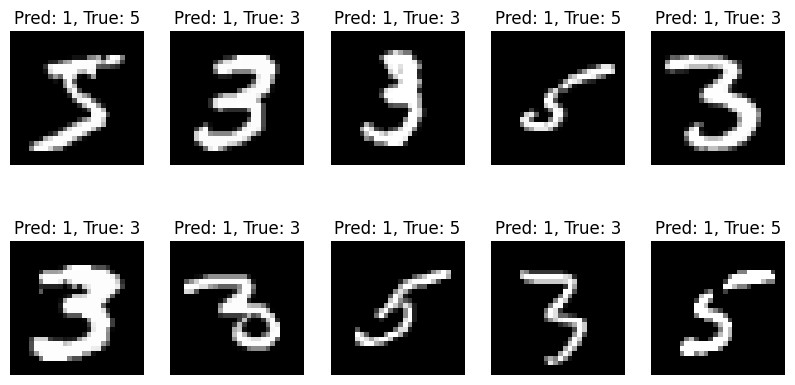

In [24]:
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))

    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.show()
else:
    print("All images were correctly classified!")

Conclusion:

- Accuracy is lower compared to 0 vs 1 classification.
- Digits 3 and 5 are visually similar.
- Data is not perfectly linearly separable.
- Perceptron has limitations on complex datasets.